In [1]:
%cd ..

/mnt/c/python_codes/LearnKalmanGain


In [9]:
import numpy as np
from matplotlib import pyplot as plt, colors, cm # Modified import style

def plot_particle_trajectories(
    particles: np.ndarray,
    true_traj: np.ndarray,
    cmap_name: str = 'viridis',
    start_time: int = None,
    end_time: int = None,
    main_fig_size: tuple = (7, 3), # New parameter for main figure size
    save_fig: bool = False,
    save_name: str = 'example_fig'
):
    """
    Visualizes particle trajectories, a true trajectory, their difference, and particle spread.

    Args:
        particles (np.ndarray): A 3D tensor of shape (J, N, d)
                                J: number of time steps
                                N: number of particles
                                d: dimension of particle state
        true_traj (np.ndarray): A 2D tensor of shape (J, d)
                                J: number of time steps
                                d: dimension of state
        cmap_name (str): Name of the Matplotlib colormap to use.
        start_time (int, optional): The starting time step index for plotting. Defaults to 0.
        end_time (int, optional): The ending time step index (exclusive) for plotting.
                                  Defaults to the total number of time steps.
        main_fig_size (tuple): Figure size (width, height) for the four main plots.
                               Defaults to (7, 3).
        save_fig (bool): If True, saves the plots. Defaults to False.
        save_name (str): Base name for saved figures. Suffixes will be added.
                         Defaults to 'example_fig'.
    """

    # 1. Validate input shapes
    # Check particles tensor dimensions
    if not isinstance(particles, np.ndarray) or particles.ndim != 3:
        raise ValueError(f"Particles tensor must be 3-dimensional (J, N, d), but got ndim={particles.ndim}")
    J_p, N, d_p = particles.shape

    # Check true_traj tensor dimensions
    if not isinstance(true_traj, np.ndarray) or true_traj.ndim != 2:
        raise ValueError(f"True trajectory tensor must be 2-dimensional (J, d), but got ndim={true_traj.ndim}")
    J_t, d_t = true_traj.shape

    # Check for consistent time steps (J) and dimensions (d)
    if J_p != J_t:
        raise ValueError(f"Time steps mismatch: particles have {J_p} and true_traj has {J_t}")
    if d_p != d_t:
        raise ValueError(f"State dimensions mismatch: particles have {d_p} and true_traj has {d_t}")

    J_orig, d = J_p, d_p # Use common J_orig (original) and d

    # 6. Handle start_time and end_time for slicing
    _start_time = 0 if start_time is None else int(start_time)
    _end_time = J_orig if end_time is None else int(end_time)

    if not (0 <= _start_time < J_orig and 0 < _end_time <= J_orig and _start_time < _end_time):
        raise ValueError(f"Invalid start_time ({_start_time}) or end_time ({_end_time}) for J_orig={J_orig}")

    # Slice the data
    particles_sliced = particles[_start_time:_end_time, :, :]
    true_traj_sliced = true_traj[_start_time:_end_time, :]
    
    # Update J for the sliced data
    current_J = true_traj_sliced.shape[0]
    if current_J == 0:
        print("Warning: Time slice is empty. No plots will be generated.")
        return

    # 2. Prepare data for plots
    # Mean of particles
    mean_particles = np.mean(particles_sliced, axis=1)  # Shape: (current_J, d)

    # Absolute difference
    abs_diff = np.abs(mean_particles - true_traj_sliced) # Shape: (current_J, d)

    # Particle spread (standard deviation across particles for each time step and dimension)
    particle_spread = np.std(particles_sliced, axis=1) # Shape: (current_J, d)

    # Data for plotting (transposed to have time on x-axis, states on y-axis for imshow)
    plot_data_list = [
        mean_particles.T,       # (d, current_J)
        true_traj_sliced.T,     # (d, current_J)
        abs_diff.T,             # (d, current_J)
        particle_spread.T       # (d, current_J)
    ]
    plot_suffixes = [
        "_mean_particles",
        "_true_trajectory",
        "_absolute_difference",
        "_particle_spread"
    ]

    # 3. Determine global color range for the 4 main plots
    all_plot_data_values = np.concatenate([data.flatten() for data in plot_data_list if data.size > 0])
    if all_plot_data_values.size == 0:
        print("Warning: All plot data is empty after slicing or processing. No plots will be generated.")
        return
        
    global_min = all_plot_data_values.min()
    global_max = all_plot_data_values.max()
    
    if global_min == global_max: # Handle case where all data is constant
        offset = 1e-6 if global_max == 0 else abs(global_max * 0.01)
        global_max += offset
        global_min -= offset # Ensure a range, even if small
        if global_min == global_max: # If still same (e.g. offset was too small for float precision)
             global_min = global_max - 1.0 # Fallback for extreme case

    norm = colors.Normalize(vmin=global_min, vmax=global_max) # Use 'colors.Normalize'
    current_cmap = plt.get_cmap(cmap_name)

    # Generate the 4 main plots
    for i, data_to_plot in enumerate(plot_data_list):
        fig, ax = plt.subplots(figsize=main_fig_size) # Use main_fig_size
        if data_to_plot.size > 0:
            ax.imshow(data_to_plot, aspect='auto', cmap=current_cmap, norm=norm, interpolation='nearest')
        
        # 7. Remove labels, title, axes, and grid
        ax.axis('off') # This removes ticks, labels, spines, etc.

        if save_fig:
            fig_path = f"{save_name}{plot_suffixes[i]}.png"
            plt.savefig(fig_path, bbox_inches='tight', pad_inches=0)
            print(f"Saved: {fig_path}")
        plt.close(fig) # Close figure to free memory

    # 3. Draw the separate, narrow colorbar
    # Colorbar height matches main figure height, width is narrow
    cbar_fig_height = main_fig_size[1]
    cbar_fig_width = 0.3 # Narrow width for the colorbar figure itself
    
    fig_cbar, ax_cbar = plt.subplots(figsize=(cbar_fig_width, cbar_fig_height))
    
    # Create a ScalarMappable for the colorbar
    scalar_mappable = cm.ScalarMappable(cmap=current_cmap, norm=norm) # Use cm.ScalarMappable
    scalar_mappable.set_array([]) # Dummy array

    cbar = plt.colorbar(scalar_mappable, cax=ax_cbar, orientation='vertical')
    cbar.set_label('State Value / Error / Std') # Label for the colorbar itself is okay

    if save_fig:
        cbar_path = f"{save_name}_colorbar.png"
        plt.savefig(cbar_path, bbox_inches='tight', pad_inches=0.05) # Small pad for colorbar
        print(f"Saved: {cbar_path}")
    plt.close(fig_cbar)

    if not save_fig:
        print("Plot generation complete. If in a script and plots aren't shown, call plt.show().")


if __name__ == '__main__':
    # Simplified Example Usage:
    J_total = 50      # Total time steps
    N_particles = 30  # Number of particles
    d_dim = 8         # Dimension of state

    # Generate some dummy data
    np.random.seed(123) # For reproducibility
    particles_data = np.random.randn(J_total, N_particles, d_dim)
    
    # Create a smoother true trajectory
    time_points = np.linspace(0, 2 * np.pi, J_total)
    true_trajectory_data = np.zeros((J_total, d_dim))
    for i in range(d_dim):
        true_trajectory_data[:, i] = np.cos(time_points + i * np.pi / (d_dim * 2)) + \
                                     np.random.randn(J_total) * 0.15

    # Simulate particle movement around the true trajectory with some noise and drift
    for t in range(J_total):
        # Particles are centered around true_trajectory but with individual noise
        particles_data[t,:,:] = true_trajectory_data[t,:] + \
                                np.random.randn(N_particles, d_dim) * 0.6
        if t > 0: # Add a slight drift component to particles
             particles_data[t,:,:] += (particles_data[t-1,:,:] - true_trajectory_data[t-1,:]) * 0.1


    print("--- Running simplified example ---")
    plot_particle_trajectories(
        particles=particles_data,
        true_traj=true_trajectory_data,
        cmap_name='plasma',          # Single colormap for the test
        start_time=5,
        end_time=45,
        main_fig_size=(3, 2.5),      # Example custom figure size for main plots
        save_fig=True,
        save_name='trajectory_single_case'
    )
    
    print("\n--- Testing with zero time steps (after slicing) ---")
    try:
        plot_particle_trajectories(
            particles_data,
            true_trajectory_data,
            start_time=10,
            end_time=50, # This will result in an empty slice
            save_fig=False 
        )
    except ValueError as e: # Should be caught by initial slice validation if start_time == end_time
        print(f"Caught expected error for empty slice due to start=end: {e}")
    
    # Test case that *should* produce an empty slice and print warning
    # if start_time < end_time check is removed from initial validation
    # but current_J == 0 check should handle it.
    # The ValueError for "start_time < end_time" will catch it first.
    # To test the "current_J == 0" warning more directly, one might need to
    # provide an empty array initially, but that would fail earlier checks.

    print("\nSimplified example finished.")

--- Running simplified example ---
Saved: trajectory_single_case_mean_particles.png
Saved: trajectory_single_case_true_trajectory.png
Saved: trajectory_single_case_absolute_difference.png
Saved: trajectory_single_case_particle_spread.png
Saved: trajectory_single_case_colorbar.png

--- Testing with zero time steps (after slicing) ---
Plot generation complete. If in a script and plots aren't shown, call plt.show().

Simplified example finished.


In [2]:
import sys
import os

from utils import plot_results_3d, plot_results_2d
from utils import partial_obs_operator, get_mean_std
from torch.utils.data import Dataset, DataLoader
from config.dataset_info import DATASET_INFO

from networks import ComplexAttentionModel, AttentionModel
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import torch
from localization import plot_GC, pairwise_distances

In [3]:
TEST_DATA = {
    'lorenz63': 'data/lorenz63/test_0_96000_v_0.150step.npy',
    'lorenz96': 'data/lorenz96/test_0_96000_v_0.150step.npy',
    'ks': 'data/ks/test_0_128000_v_1.000step.npy'
}

d = np.load(TEST_DATA['lorenz63'])
print(d[1000:].shape)

(96000, 1, 3)


In [4]:
print(d[1001:].shape)

(95999, 1, 3)


/tmp/ipykernel_402301/664978781.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  records = torch.load(data_path)


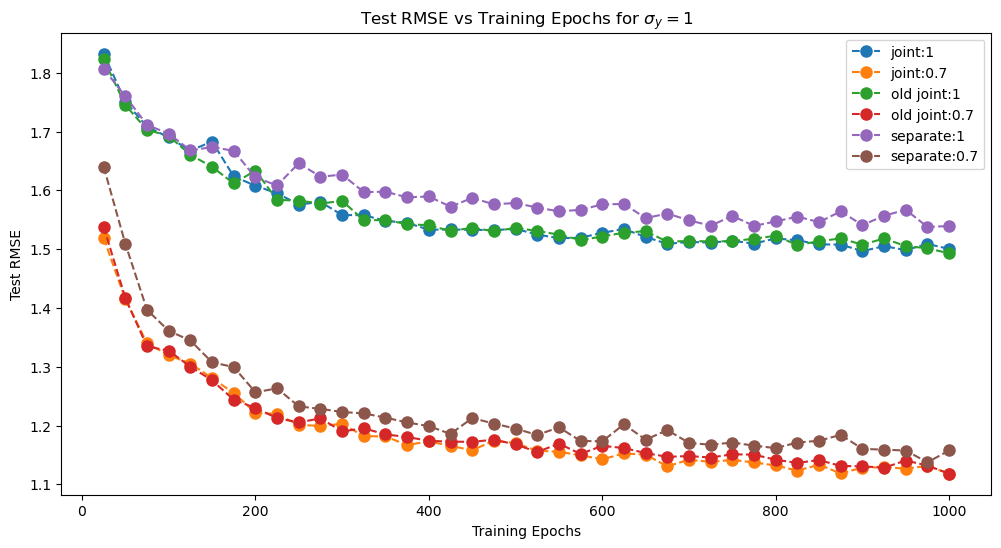

In [5]:
folder_name_list = [
    "2024-12-01_16-40lorenz96_1.0_10_60_8192_EnST_joint",
    "2024-11-28_00-50lorenz96_0.7_10_60_8192_EnST_joint",
    "2024-11-26_20-44lorenz96_1.0_10_60_8192_EnST_joint",
    "2024-11-27_00-50lorenz96_0.7_10_60_8192_EnST_joint",
    "2024-11-05_17-59lorenz96_1.0_10_60_8192_EnST_normalized_l2",
    "2024-11-06_13-43lorenz96_0.7_10_60_8192_EnST_normalized_l2"]
# folder_name_list = ["2024-11-06_11-12lorenz96_0.7_10_60_8192_EnST_l2",
#                     "2024-11-06_13-43lorenz96_0.7_10_60_8192_EnST_normalized_l2"]
# method_name_list = ['joint:1', 'joint:0.7', "v2:1", "v2:0.7", "v1:1", "v1:0.7"]
method_name_list = ['joint:1', 'joint:0.7', 'old joint:1', 'old joint:0.7', 'separate:1', 'separate:0.7']

test_loss_list = []
test_epoch_list = []
for folder_name in folder_name_list:
    data_path = os.path.join("save", folder_name, "training_records.pt")
    records = torch.load(data_path)
    test_loss_list.append(records['test_loss'])
    test_epoch_list.append(records['test_epochs'])
    
def to_cpu(L):
    return [l.cpu() if isinstance(l, torch.Tensor) else l for l in L]

plt.figure(figsize=(12, 6))  # Adjusted figure size to elongate x-axis
for i in range(len(folder_name_list)):
    plt.plot(test_epoch_list[i], to_cpu(test_loss_list[i][1:]), linestyle='--', marker='o', markersize=8, label=method_name_list[i]) 
plt.legend(loc='upper right')
plt.title(r'Test RMSE vs Training Epochs for $\sigma_y=1$')
plt.xlabel("Training Epochs")
plt.ylabel("Test RMSE")

# plt.savefig(os.path.join('save/figures', f"Test_RMSE_vs_Training_Epochs_10.png"), bbox_inches="tight", dpi=200)
plt.show()

/tmp/ipykernel_402301/284091861.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  records = torch.load(data_path)


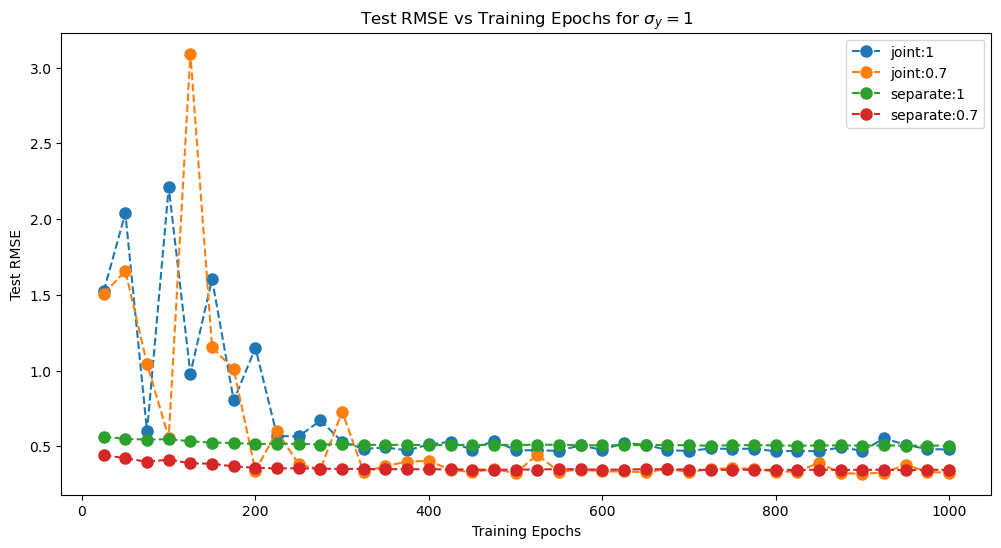

In [6]:
folder_name_list = [
    "2024-11-28_04-56ks_1.0_10_60_8192_EnST_joint",
    "2024-12-01_20-43ks_0.7_10_60_8192_EnST_joint",
    "2024-11-13_13-41ks_1.0_10_60_8192_EnST_normalized_l2",
    "2024-11-13_23-15ks_0.7_10_60_8192_EnST_normalized_l2"]
# method_name_list = ['joint:1', 'joint:0.7', "v2:1", "v2:0.7", "v1:1", "v1:0.7"]
method_name_list = ['joint:1', 'joint:0.7', 'separate:1', 'separate:0.7']

test_loss_list = []
test_epoch_list = []
for folder_name in folder_name_list:
    data_path = os.path.join("save", folder_name, "training_records.pt")
    records = torch.load(data_path)
    test_loss_list.append(records['test_loss'])
    test_epoch_list.append(records['test_epochs'])
    
def to_cpu(L):
    return [l.cpu() if isinstance(l, torch.Tensor) else l for l in L]

plt.figure(figsize=(12, 6))  # Adjusted figure size to elongate x-axis
for i in range(len(folder_name_list)):
    plt.plot(test_epoch_list[i], to_cpu(test_loss_list[i][1:]), linestyle='--', marker='o', markersize=8, label=method_name_list[i]) 
plt.legend(loc='upper right')
plt.title(r'Test RMSE vs Training Epochs for $\sigma_y=1$')
plt.xlabel("Training Epochs")
plt.ylabel("Test RMSE")

# plt.savefig(os.path.join('save/figures', f"Test_RMSE_vs_Training_Epochs_10.png"), bbox_inches="tight", dpi=200)
plt.show()

/tmp/ipykernel_156801/3217269885.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  records = torch.load(data_path)


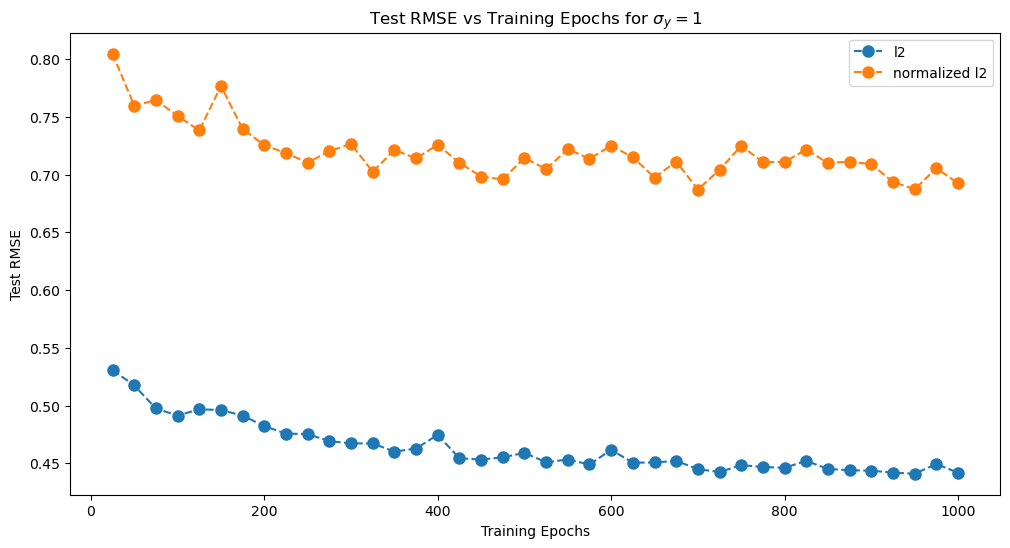

In [5]:
folder_name_list = ["2024-12-05_19-57lorenz63_0.7_10_60_8192_EnST_joint",
                    "2024-12-05_17-49lorenz63_1.0_10_60_8192_EnST_joint"]
method_name_list = ['l2', 'normalized l2']

test_loss_list = []
test_epoch_list = []
for folder_name in folder_name_list:
    data_path = os.path.join("save", folder_name, "training_records.pt")
    records = torch.load(data_path)
    test_loss_list.append([t.cpu() for t in records['test_loss']])
    test_epoch_list.append(records['test_epochs'])

plt.figure(figsize=(12, 6))  # Adjusted figure size to elongate x-axis
for i in range(len(folder_name_list)):
    plt.plot(test_epoch_list[i], test_loss_list[i][1:], linestyle='--', marker='o', markersize=8, label=method_name_list[i]) 
plt.legend(loc='upper right')
plt.title(r'Test RMSE vs Training Epochs for $\sigma_y=1$')
plt.xlabel("Training Epochs")
plt.ylabel("Test RMSE")

# plt.savefig(os.path.join('save/figures', f"Test_RMSE_vs_Training_Epochs_10.png"), bbox_inches="tight", dpi=200)
plt.show()

In [24]:
folder_name = '2025-03-25_05-08lorenz63_0.7_10_60_8192_EnST_joint'

ens_list = [5,10,15,20,40,60,100]
# ens_list = [5]
for N in ens_list:
    data_path = os.path.join("save", folder_name, f"output_records_{N}.pt")
    records = torch.load(data_path)
    print(N, f"{records['nn']['mean_rmse']:.3f}")

/tmp/ipykernel_402301/3309279815.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  records = torch.load(data_path)


5 0.486
10 0.483
15 0.492
20 0.503
40 0.523
60 0.535
100 0.549


In [25]:
folder_name = '2024-12-09_13-38lorenz63_0.7_20_60_8192_EnST_tuned_joint'

ens_list = [5,10,15,20,40,60,100]
# ens_list = [5]
for N in ens_list:
    data_path = os.path.join("save", folder_name, f"output_records_{N}.pt")
    records = torch.load(data_path)
    print(N, f"{records['nn']['mean_rmse']:.3f}")

/tmp/ipykernel_402301/3374836668.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  records = torch.load(data_path)


5 0.462
10 0.450
15 0.443
20 0.433
40 0.443
60 0.431
100 0.434


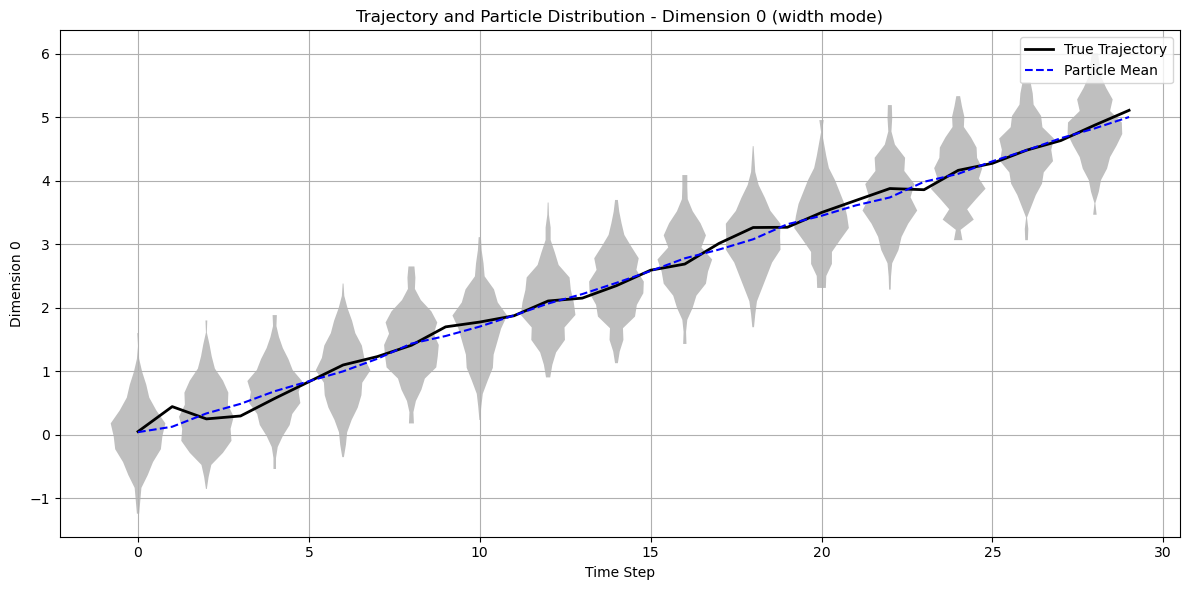

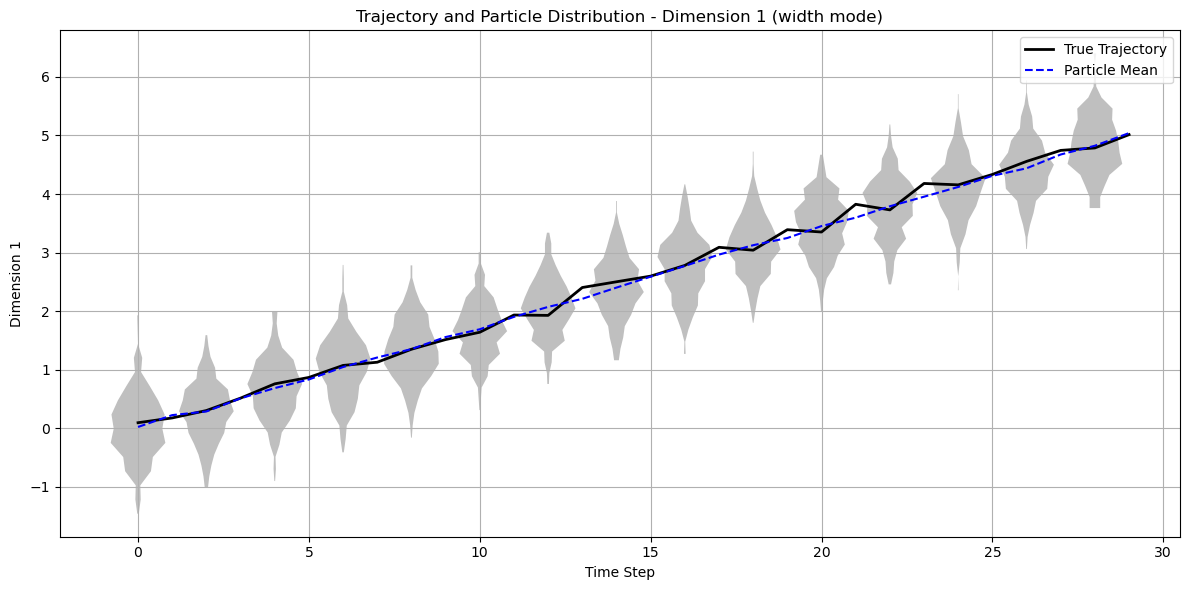

/tmp/ipykernel_685582/2889594553.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Oranges')


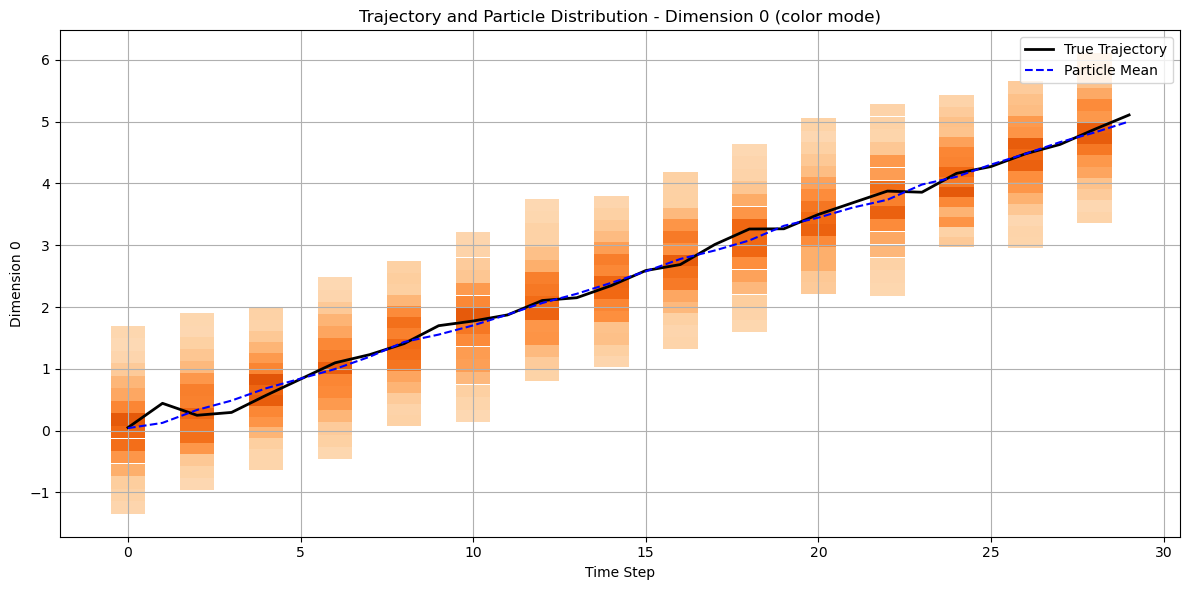

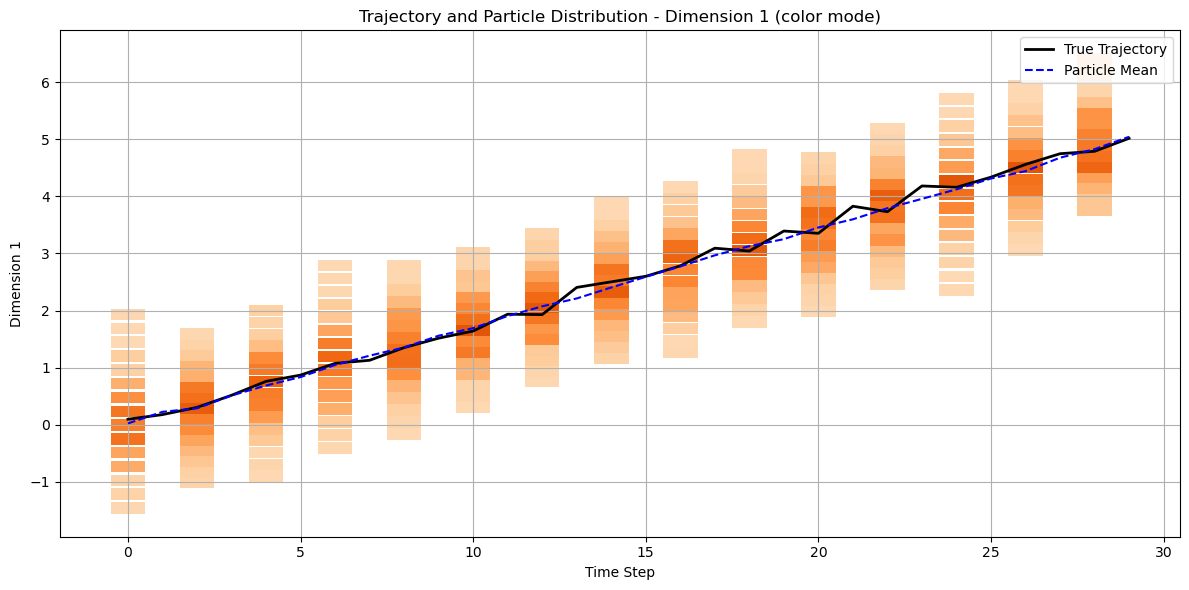

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Reduced synthetic data size to avoid memory issues
J, N, d = 30, 400, 2  # smaller time steps, fewer particles and dimensions
torch.manual_seed(0)

# Simulated particles: shape [J, N, d]
particles = torch.randn(J, N, d) * 0.5 + torch.linspace(0, 5, J).unsqueeze(1).unsqueeze(2)
# Simulated true trajectory: shape [J, d]
true_traj = torch.linspace(0, 5, J).unsqueeze(1).repeat(1, d) + torch.randn(J, d) * 0.1

import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def plot_particle_trajectories_with_histograms(particles: torch.Tensor, 
                                                true_traj: torch.Tensor, 
                                                dim_indices: list,
                                                mode: str = 'width',
                                                save_fig: bool = False,
                                                save_name: str = 'fig.png'):
    J, N, d = particles.shape
    time_steps = np.arange(J)
    step_width = 1.0

    for dim in dim_indices:
        plt.figure(figsize=(12, 6))
        
        plt.plot(time_steps, true_traj[:, dim], label='True Trajectory', color='black', linewidth=2)
        particle_mean = particles[:, :, dim].mean(dim=1)
        plt.plot(time_steps, particle_mean, label='Particle Mean', color='blue', linestyle='--')

        if mode == 'color':
            all_hist_values = []
            for t in range(0, J, 2):
                data = particles[t, :, dim].numpy()
                hist, _ = np.histogram(data, bins=15, density=True)
                all_hist_values.extend(hist)
            global_max = max(all_hist_values)

        for t in range(0, J, 2):
            data = particles[t, :, dim].numpy()
            hist, bins = np.histogram(data, bins=15, density=True)
            bin_centers = 0.5 * (bins[:-1] + bins[1:])

            if mode == 'width':
                hist_norm = hist / hist.max() * 0.8 if hist.max() > 0 else hist
                plt.fill_betweenx(bin_centers, t - hist_norm, t + hist_norm,
                                  facecolor='gray', edgecolor='none', alpha=0.5)
            elif mode == 'color':
                cmap = cm.get_cmap('Oranges')
                for h, center in zip(hist, bin_centers):
                    norm_val = h / global_max if global_max > 0 else 0.0
                    color = cmap(0.2 + 0.5 * norm_val)
                    plt.fill_between([t - step_width / 2, t + step_width / 2],
                                     center - 0.1, center + 0.1,
                                     color=color, linewidth=0)

        plt.xlabel('Time Step')
        plt.ylabel(f'States')
        plt.title(f'Dimension Index {dim}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_fig:
            plt.savefig(save_name, dpi=150)
            plt.close()
        else:
            plt.show()



# width 模式（默认）
plot_particle_trajectories_with_histograms(particles, true_traj, [0, 1], mode='width')

# color 模式（橙黄色）
plot_particle_trajectories_with_histograms(particles, true_traj, [0, 1], mode='color')

